In [2]:
import pandas as pd

# Chargement des données
results = pd.read_csv('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/results.csv')
goalscorers = pd.read_csv('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/goalscorers.csv')
shootouts = pd.read_csv('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/shootouts.csv')

print(results.shape)
results.head()

(49287, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
# Infos générales
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  str    
 1   home_team   49287 non-null  str    
 2   away_team   49287 non-null  str    
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  str    
 6   city        49287 non-null  str    
 7   country     49287 non-null  str    
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 5.9 MB


In [4]:
# Valeurs manquantes
results.isna().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [5]:
# Créer la variable cible : résultat (Home Win, Draw, Away Win)
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

results['result'] = results.apply(get_result, axis=1)

# Distribution de la variable cible
results['result'].value_counts(normalize=True)

result
Home Win    0.489094
Away Win    0.282265
Draw        0.228640
Name: proportion, dtype: float64

In [6]:
# Supprimer les lignes sans score
results = results.dropna(subset=['home_score', 'away_score'])

print(results.shape)
results['result'].value_counts()

(49215, 10)


result
Home Win    24106
Away Win    13912
Draw        11197
Name: count, dtype: int64

In [7]:
# Distribution des tournois
results['tournament'].value_counts().head(10)

tournament
Friendly                                18252
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            964
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
Name: count, dtype: int64

<Axes: title={'center': 'Evolution des résultats par année'}, xlabel='year'>

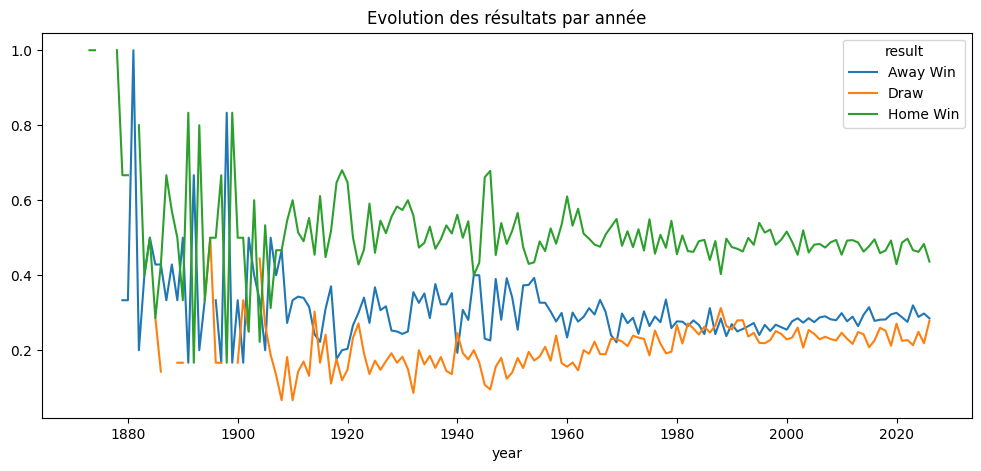

In [8]:
# Evolution dans le temps
results['date'] = pd.to_datetime(results['date'])
results['year'] = results['date'].dt.year
results.groupby('year')['result'].value_counts(normalize=True).unstack().plot(figsize=(12,5), title='Evolution des résultats par année')

In [9]:
# Garder uniquement les matchs après 1990
results_recent = results[results['year'] >= 1990]
print(results_recent.shape)
results_recent['result'].value_counts(normalize=True)

(32101, 11)


result
Home Win    0.484346
Away Win    0.280334
Draw        0.235320
Name: proportion, dtype: float64